I chose to use a series of 3 conv layers and maxpooling because the conv layers can identify important features that distinguish between cats and dogs and then the dense layer combines the findings of the features and produces a sigmoid output for classifying a cat or dog. The first conv layer will find simple patterns like edges while the ones after will discover more complex shapes like a paw or head shape. The max pooling layers help decrease parameter count but still retain important patterns being found. Dataset: https://www.tensorflow.org/datasets/catalog/cats_vs_dogs

final validation:

val_accuracy: 0.8203 - val_auc: 0.9003 - val_loss: 0.6760 - val_precision: 0.7826 - val_recall: 0.9046

test set:

accuracy: 0.8190 - auc: 0.8983 - loss: 0.6893 - precision: 0.7725 - recall: 0.9057

The metrics show that the model generalized relatively well outside of its training data and that it has reasonable balanced of precision and recall. Specifically the AUC of 0.8988 shows how it has some solid understanding in differentiating between classes.

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


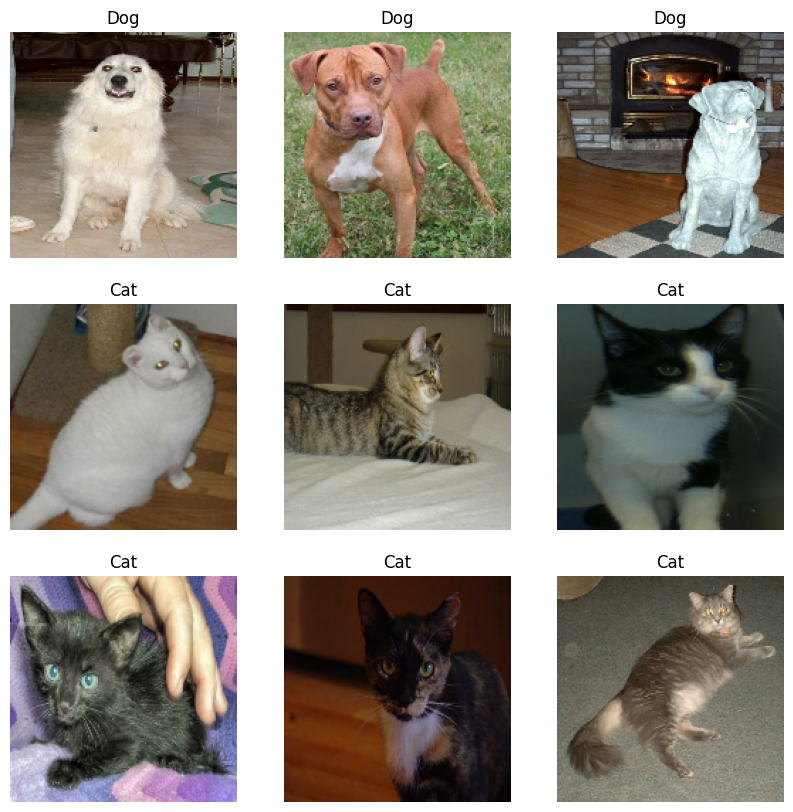

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.6306 - auc: 0.6906 - loss: 0.6340 - precision: 0.6297 - recall: 0.6197 - val_accuracy: 0.7167 - val_auc: 0.7957 - val_loss: 0.5559 - val_precision: 0.7308 - val_recall: 0.7181
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7581 - auc: 0.8379 - loss: 0.4984 - precision: 0.7650 - recall: 0.7397 - val_accuracy: 0.7855 - val_auc: 0.8726 - val_loss: 0.4569 - val_precision: 0.7632 - val_recall: 0.8499
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8145 - auc: 0.8936 - loss: 0.4135 - precision: 0.8157 - recall: 0.8087 - val_accuracy: 0.8130 - val_auc: 0.8928 - val_loss: 0.4151 - val_precision: 0.8237 - val_recall: 0.8134
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8459 - auc: 0.9269 - loss: 0.3458 - precision: 0.8475 - recall: 0.8406 - val_accuracy: 0.8199 - val_auc: 0.8988 - val_loss: 0.4236 - val_precision: 0.8006 - val_recall: 0.8690
Epoch 5/10
582/582 ━━━━━━━━

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import random
import os

SEED = 42

#fix randomization
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#80 10 10 split
(train_ds, val_ds, test_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    shuffle_files=False,
    with_info=True,
    as_supervised=True
)

IMG_SIZE = 160
BATCH_SIZE = 32

#rescale images
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

#create datasets
train_ds = train_ds.map(preprocess).shuffle(1000, seed=SEED, reshuffle_each_iteration=False).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#show the images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title("Dog" if labels[i] == 1 else "Cat")
        plt.axis("off")
plt.show()

#3 convs 1 dense
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

results = model.evaluate(test_ds)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

Part 2

In [2]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

#freeze the existing model
base_model.trainable = False

#add classifier based on the existing outputs
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

results = model.evaluate(test_ds)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9636 - auc: 0.9933 - loss: 0.0990 - precision: 0.9635 - recall: 0.9632 - val_accuracy: 0.9811 - val_auc: 0.9971 - val_loss: 0.0572 - val_precision: 0.9802 - val_recall: 0.9834
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9791 - auc: 0.9975 - loss: 0.0558 - precision: 0.9790 - recall: 0.9789 - val_accuracy: 0.9802 - val_auc: 0.9970 - val_loss: 0.0586 - val_precision: 0.9785 - val_recall: 0.9834
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9843 - auc: 0.9985 - loss: 0.0422 - precision: 0.9851 - recall: 0.9832 - val_accuracy: 0.9789 - val_auc: 0.9957 - val_loss: 0.0673 - val_precision: 0.9769 - val_recall: 0.9826
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9886 - auc: 0.9990 - loss: 0.0319 - precision: 0.9889 - recall: 0.9880 - val_accuracy: 0.9759 - val_auc: 0.9951 - val_loss: 0.0766 - val_precision: 0.9

Part 2

A mobile net transfer learn was able to outperform significantly and reach the following metrics

 accuracy: 0.9811 - auc: 0.9927 - loss: 0.0992 - precision: 0.9811 - recall: 0.9811

 It performed much better presumably because the existing mobile net already has a lot of useful embedding and understanding of images and therefore by starting from learning on it, it starts in a place where it already has a much
 greater understanding of images and maybe even animals or cats and dogs specifically. It already likely has an understanding of outlines of objects and how to interpret textures or changes in textures.

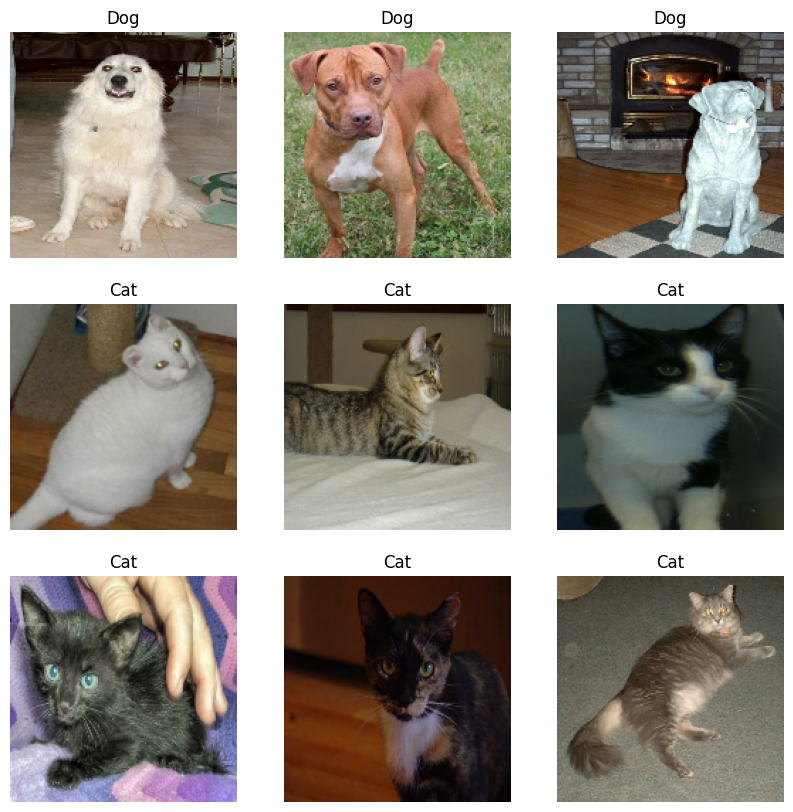

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6083 - auc: 0.6482 - loss: 0.6638 - precision: 0.6131 - recall: 0.5703 - val_accuracy: 0.6784 - val_auc: 0.7508 - val_loss: 0.6015 - val_precision: 0.6701 - val_recall: 0.7479
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6765 - auc: 0.7403 - loss: 0.5998 - precision: 0.6828 - recall: 0.6496 - val_accuracy: 0.6969 - val_auc: 0.7805 - val_loss: 0.5745 - val_precision: 0.6778 - val_recall: 0.7919
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7140 - auc: 0.7824 - loss: 0.5623 - precision: 0.7249 - recall: 0.6824 - val_accuracy: 0.7519 - val_auc: 0.8321 - val_loss: 0.5272 - val_precision: 0.7258 - val_recall: 0.8383
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7348 - auc: 0.8096 - loss: 0.5331 - precision: 0.7418 - recall: 0.7139 - val_accuracy: 0.7799 - val_auc: 0.8628 - val_loss: 0.4708 - val_precision: 0.7690 - val_recall: 0.8226
Epoch 5/10
582/582 ━━━━━━━━

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


(train_ds, val_ds, test_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    shuffle_files=False,
    with_info=True,
    as_supervised=True
)

IMG_SIZE = 160
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000, seed=SEED, reshuffle_each_iteration=False).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title("Dog" if labels[i] == 1 else "Cat")
        plt.axis("off")
plt.show()

#data augmentation does horizontal flipping and small perturbations
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

#same as the first model except with data augmentation
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

history = model.fit(train_ds, epochs=10, validation_data=val_ds)
results = model.evaluate(test_ds)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

accuracy: 0.8353 - auc: 0.9183 - loss: 0.3697 - precision: 0.8413 - recall: 0.8276
I used horizontal mirroring, rotation zoom and translation and this resulted in a small improvement in accuracy from .8190 to 0.8353. This could be because the model is made to be more robust in that it doesn't memorize images and instead learns more general patterns and how to classify the images. It also effectively allows the dataset to be larger since horizontal mirroring doubles the amount of unique data points and the model can learn to be independent of horizontal orientation. Because of this overfitting should be reduced and it should reduce any hidden biases in the dataset, for example if cat pictures happen to be a bit more to the left and dog images a bit more to the right that would create a bias but by flipping we can eliminate that bias.